# 03 BMRA

Run BMRA based on global responses derived from the pathway activity predictions.

In [1]:
import pandas as pd
import numpy as np
import os
import bmra

In [2]:
cell_line = 'BC3C'

data_dir =f'/home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_bmra/blca_publication_OUTPUT_bmra_{cell_line}_oct_aug/'
data_dir_1 = os.path.join(data_dir, f'00_outputs_2020_{cell_line}/')
data_dir_2 = os.path.join(data_dir, f'01_outputs_2020_{cell_line}/')

info_dir =f"/home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_LINCS/00_outputs_2020_{cell_line}/"

out_dir = os.path.join(data_dir,f'02_outputs_2020_{cell_line}/')


os.makedirs(out_dir, exist_ok = True)

## Load data

### Global responses

Assembled from global responses calculated from predicted pathway activities, and DPD global responses.

In [3]:
def assemble_R_global(pathway_rglobal_file, dpd_rglobal_file):
    """
    Assemble full R_global matrix
    """
    R_global_modules_df = pd.read_csv(pathway_rglobal_file, index_col = 0)

    perts = R_global_modules_df.columns.tolist()

    R_global_DPD_df = pd.read_csv(dpd_rglobal_file, index_col=0).T

    # filter by perts list
    R_global_DPD_df = R_global_DPD_df[R_global_DPD_df.index.isin(perts)]

    # sort by perts list
    R_global_DPD_df["sort_col"] = R_global_DPD_df.index.map({val: i for i, val in enumerate(perts)})
    R_global_DPD_df = R_global_DPD_df.sort_values("sort_col")
    R_global_DPD_df = R_global_DPD_df.drop("sort_col", axis = 1)

    # transpose
    R_global_DPD_df = R_global_DPD_df.T

    R_global_df = pd.concat([R_global_modules_df, R_global_DPD_df])

    return R_global_df

In [4]:
R_global_df = assemble_R_global(
    pathway_rglobal_file = os.path.join(data_dir_2, "R_global_annotated.csv"),
    dpd_rglobal_file = os.path.join(data_dir_1, "R_global_DPDonly_annotated.csv"),
)

modules = R_global_df.index.tolist()
exp_ids = R_global_df.columns.tolist()

R_global = R_global_df.values
n_modules = R_global.shape[0]

print(R_global.shape)
display(R_global_df)

(15, 144)


,ASG002_BC3C_24H:A10,ASG002_BC3C_24H:A11,ASG002_BC3C_24H:A19,ASG002_BC3C_24H:A20,ASG002_BC3C_24H:A21,ASG002_BC3C_24H:B10,ASG002_BC3C_24H:B11,ASG002_BC3C_24H:B14,ASG002_BC3C_24H:B15,ASG002_BC3C_24H:C13,...,SMAD3in_V11,SMAD3in_V12,SMAD3in_V13,SMAD3in_V14,SMAD3in_V15,SMAD3in_V16,SMAD3in_V17,SMAD3in_V18,SMAD3in_V19,SMAD3in_V20
Androgen,-0.052095,-0.009089,0.002049,-0.039778,0.001388,0.020524,0.004034,0.016122,0.021111,0.035960,...,0.012764,0.004873,-0.002185,0.001210,0.000265,0.007804,-0.004034,0.008464,0.003308,0.021534
CDK1_2,-0.768273,-0.614755,0.075325,-0.079904,0.089680,-0.282097,0.017335,-0.287704,0.120143,0.055118,...,-0.480374,-0.437256,-0.400662,-0.417611,-0.386523,-0.403037,-0.394879,-0.437924,-0.435277,-0.472746
CDK4_6,-0.092411,-0.210950,-0.265290,-0.141717,-0.163803,-0.103093,-0.016878,-0.028821,-0.218272,-0.010762,...,0.198343,0.189244,0.177556,0.140909,0.138950,0.150663,0.172020,0.164796,0.190069,0.163447
EGFR,0.598441,0.498146,0.228981,0.371224,0.486402,0.113873,-0.415507,0.263087,0.286899,-0.047077,...,-1.225406,-0.821121,-0.806630,-0.706686,-0.677071,-0.692529,-0.744456,-0.899220,-0.879137,-0.933293
Estrogen,-0.125409,-0.208362,-0.209045,-0.410515,-0.943351,-0.311418,-0.084928,-0.236092,-0.162215,-0.039650,...,-0.296804,-0.265812,-0.238593,-0.263146,-0.243248,-0.251675,-0.229277,-0.276421,-0.260162,-0.304476
FGFR,-0.110612,-0.176118,-0.089455,0.051478,-0.028281,-0.407428,-0.033354,-0.026855,-0.061340,-0.301084,...,-0.854376,-0.700109,-0.638602,-0.638719,-0.569303,-0.617494,-0.624983,-0.711393,-0.717033,-0.792202
PI3K,-1.910966,-1.699159,-1.425575,-1.241725,-0.701968,0.295109,-0.143859,-0.177113,-0.848384,-0.273685,...,-0.177298,-0.139084,-0.120742,-0.114059,-0.099701,-0.140369,-0.131804,-0.135862,-0.155846,-0.180301
p53,-0.210364,-0.217898,-0.125995,-0.404942,0.049696,-1.630029,-1.476804,-0.119178,-0.087987,-1.326474,...,0.016668,-0.000954,0.011649,0.021806,-0.006903,0.014973,0.042119,-0.003211,0.037732,0.001231
TOP2A,-0.194672,0.095617,-0.233097,-0.163237,-0.127492,0.043017,0.079112,-2.000421,-0.196845,-0.298854,...,0.108585,0.092367,0.083997,0.071913,0.067490,0.079518,0.083257,0.086786,0.095575,0.097503
Src,-0.928588,-1.677513,0.522790,-1.205287,0.571455,-1.127273,0.495578,0.394501,0.397006,0.447192,...,-0.127760,-0.154060,-0.098183,-0.127832,-0.056520,-0.117954,-0.098885,-0.113815,-0.155771,-0.166602


In [5]:
print(R_global_df.values.min())
print(R_global_df.values.max())

-141.3271606788109
23.679038382410333


### Perturbation matrix

In [6]:
inhib_conc_df = pd.read_csv(os.path.join(data_dir_1, "inhib_conc_annotated.csv"), index_col = 0)
#LFC_PLCg = pd.read_csv(os.path.join(info_dir,"PLCg_Data_log_2020.csv"),index_col=0)
#inhib_conc = inhib_conc_df.drop(columns=LFC_PLCg.index).values
inhib_conc = inhib_conc_df.values

n_DPDs = R_global.shape[0] - inhib_conc.shape[0]

pert_modules = np.where(inhib_conc != 0, 1, 0)
pert_DPD = np.zeros((n_DPDs, len(exp_ids)))

pert = np.vstack([pert_modules, pert_DPD])

print(pert.shape)
print(pert)

(15, 144)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### Networks

In [7]:
# empty prior
#G_prior = np.zeros((n_modules, n_modules))
G_prior_df = pd.read_excel(os.path.join(info_dir, "ALL_DATA_2020_oct25.xlsx"), sheet_name = "prior_net_work", index_col = 0)

G_prior = G_prior_df.values
G_prior_df

,CDK1_2,CDK4_6,EGFR,PI3K,FGFR,TOP2A,p53,Src,TGFb,Estrogen,Androgen,SMAD3,blca_inv,blca_onc,surv_coef
CDK1_2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
CDK4_6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
EGFR,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
PI3K,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
FGFR,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
TOP2A,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
p53,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Src,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
TGFb,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Estrogen,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
#G_prior_r_df = pd.read_excel(os.path.join(info_dir, "ALL_DATA_2020.xlsx"), sheet_name = "prior_r", index_col = 0)

#G_prior_r = G_prior_r_df.values
#G_prior_r_df

In [9]:
G_not = np.eye(n_modules)
G_not[:, n_modules - n_DPDs :] = 1

G_not

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0.

## Run BMRA

In [10]:
n_gibbs = 200_000
n_window = 5_000

mode = "all"
n_iterations = 1

In [11]:
A_mean, A_sd, r_mean, r_sd = bmra.run_bmra(R_global,
            pert,
            G_prior,
            G_not,
            #r_prior = G_prior_r,
            n_gibbs = n_gibbs,
            n_window = n_window,
            mode = mode,
            n_iterations = n_iterations,
        )

A_mean_df = pd.DataFrame(A_mean, index = modules, columns = modules)
A_sd_df = pd.DataFrame(A_sd, index = modules, columns = modules)
r_mean_df = pd.DataFrame(r_mean, index = modules, columns = modules)
r_sd_df = pd.DataFrame(r_sd, index = modules, columns = modules)

display(A_mean_df)
display(A_sd_df)
display(r_mean_df)
display(r_sd_df)

A_mean_df.to_csv(os.path.join(out_dir, "A_mean.csv"))
A_sd_df.to_csv(os.path.join(out_dir, "A_sd.csv"))
r_mean_df.to_csv(os.path.join(out_dir, "r_mean.csv"))
r_sd_df.to_csv(os.path.join(out_dir, "r_sd.csv"))

,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.001672,0.000000,0.000000,0.000328,0.000000,0.000000,0.0,0.0,0.0
CDK1_2,0.000000,0.000000,0.001410,0.279000,0.000000,1.000000,1.000000,0.000000,0.000000,0.409037,0.000000,0.764621,0.0,0.0,0.0
CDK4_6,0.052759,0.000000,0.000000,0.994082,1.000000,0.001452,0.001050,0.000197,0.175109,0.000379,0.059329,0.006083,0.0,0.0,0.0
EGFR,0.480822,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.003865,0.000000,1.000000,0.0,0.0,0.0
Estrogen,0.000000,0.000000,0.439268,0.000466,0.000000,1.000000,1.000000,0.000000,0.001789,0.823565,0.026330,0.005871,0.0,0.0,0.0
FGFR,0.002711,0.000000,0.315498,1.000000,0.322820,0.000000,0.000000,0.709712,0.000000,0.000000,1.000000,1.000000,0.0,0.0,0.0
PI3K,0.000000,1.000000,0.000000,1.000000,0.181762,0.000000,0.000000,0.000000,1.000000,0.187017,1.000000,0.961986,0.0,0.0,0.0
p53,0.000000,0.000325,0.005254,1.000000,0.000888,0.000567,0.693299,0.000000,0.156128,0.001219,0.000000,0.001477,0.0,0.0,0.0
TOP2A,0.000000,0.000000,0.000000,1.000000,0.695492,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.331987,0.000000,0.668013,1.000000,0.000000,0.331987,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.000000,0.000000e+00,0.000000e+00,3.330669e-16,0.000000e+00,0.000000e+00,4.085618e-02,0.000000e+00,0.000000e+00,0.018107,0.000000e+00,0.000000e+00,0.0,0.0,0.0
CDK1_2,0.000000,0.000000e+00,3.751816e-02,4.485075e-01,0.000000e+00,9.992007e-16,9.992007e-16,0.000000e+00,0.000000e+00,0.491656,0.000000e+00,4.242357e-01,0.0,0.0,0.0
CDK4_6,0.223552,0.000000e+00,0.000000e+00,7.670342e-02,4.440892e-16,3.807980e-02,3.239107e-02,1.402834e-02,3.800604e-01,0.019475,2.362390e-01,7.775761e-02,0.0,0.0,0.0
EGFR,0.499632,0.000000e+00,1.998401e-15,0.000000e+00,0.000000e+00,1.998401e-15,1.998401e-15,0.000000e+00,0.000000e+00,0.062047,0.000000e+00,1.998401e-15,0.0,0.0,0.0
Estrogen,0.000000,0.000000e+00,4.962979e-01,2.158088e-02,0.000000e+00,1.776357e-15,1.776357e-15,0.000000e+00,4.226312e-02,0.381190,1.601148e-01,7.639567e-02,0.0,0.0,0.0
FGFR,0.051997,0.000000e+00,4.647141e-01,3.330669e-16,4.675546e-01,0.000000e+00,0.000000e+00,4.538950e-01,0.000000e+00,0.000000,3.330669e-16,3.330669e-16,0.0,0.0,0.0
PI3K,0.000000,4.662937e-15,0.000000e+00,4.662937e-15,3.856483e-01,0.000000e+00,0.000000e+00,0.000000e+00,4.662937e-15,0.389925,4.662937e-15,1.912295e-01,0.0,0.0,0.0
p53,0.000000,1.803797e-02,7.229554e-02,1.110223e-15,2.979049e-02,2.381371e-02,4.611243e-01,0.000000e+00,3.629769e-01,0.034896,0.000000e+00,3.840128e-02,0.0,0.0,0.0
TOP2A,0.000000,0.000000e+00,0.000000e+00,1.110223e-16,4.601987e-01,0.000000e+00,1.110223e-16,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.0
Src,0.000000,4.709263e-01,0.000000e+00,4.709263e-01,1.776357e-15,0.000000e+00,4.709263e-01,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.000000,0.000000,0.000000,-0.035480,0.000000,0.000000,0.000025,0.000000e+00,0.000000,1.900178e-07,0.000000,0.000000,0.0,0.0,0.0
CDK1_2,0.000000,0.000000,0.000202,0.042080,0.000000,0.216342,0.206669,0.000000e+00,0.000000,2.893489e-02,0.000000,0.160057,0.0,0.0,0.0
CDK4_6,-0.016081,0.000000,0.000000,-0.104579,0.138242,0.000112,0.000058,-1.033984e-07,0.018501,5.492147e-06,-0.081872,-0.000632,0.0,0.0,0.0
EGFR,-0.222204,0.000000,-0.283350,0.000000,0.000000,0.450677,-0.262411,0.000000e+00,0.000000,-2.351614e-04,0.000000,0.420575,0.0,0.0,0.0
Estrogen,0.000000,0.000000,0.092802,0.000025,0.000000,0.244510,0.133503,0.000000e+00,0.000179,7.165079e-02,-0.052992,0.000583,0.0,0.0,0.0
FGFR,0.000817,0.000000,0.061189,0.311785,0.053065,0.000000,0.000000,7.208781e-02,0.000000,0.000000e+00,4.878345,0.245204,0.0,0.0,0.0
PI3K,0.000000,0.336434,0.000000,-0.265739,0.037670,0.000000,0.000000,0.000000e+00,0.534515,-1.983785e-02,3.382833,0.218647,0.0,0.0,0.0
p53,0.000000,0.000004,0.000962,0.140728,0.000061,-0.000005,0.094689,0.000000e+00,0.037171,2.658842e-05,0.000000,-0.000157,0.0,0.0,0.0
TOP2A,0.000000,0.000000,0.000000,-0.150715,0.096582,0.000000,0.135379,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.106179,0.000000,0.131477,0.501187,0.000000,-0.086791,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.000000,0.000000,0.000000,0.007742,0.000000,0.000000,0.000651,0.000000,0.000000,0.000034,0.000000,0.000000,0.0,0.0,0.0
CDK1_2,0.000000,0.000000,0.005410,0.069764,0.000000,0.035735,0.031332,0.000000,0.000000,0.036762,0.000000,0.092228,0.0,0.0,0.0
CDK4_6,0.070401,0.000000,0.000000,0.017349,0.021890,0.003092,0.001936,0.000007,0.042104,0.000387,0.334828,0.008208,0.0,0.0,0.0
EGFR,0.238894,0.000000,0.042868,0.000000,0.000000,0.031963,0.019396,0.000000,0.000000,0.003888,0.000000,0.034903,0.0,0.0,0.0
Estrogen,0.000000,0.000000,0.109386,0.001148,0.000000,0.030510,0.023164,0.000000,0.004368,0.038434,0.324665,0.007854,0.0,0.0,0.0
FGFR,0.016238,0.000000,0.093548,0.025668,0.079429,0.000000,0.000000,0.050306,0.000000,0.000000,0.344867,0.043530,0.0,0.0,0.0
PI3K,0.000000,0.038441,0.000000,0.036875,0.083039,0.000000,0.000000,0.000000,0.047970,0.043452,0.456139,0.063170,0.0,0.0,0.0
p53,0.000000,0.000862,0.014314,0.036384,0.002507,0.000790,0.069558,0.000000,0.089764,0.000991,0.000000,0.004795,0.0,0.0,0.0
TOP2A,0.000000,0.000000,0.000000,0.019695,0.069317,0.000000,0.025255,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.154775,0.000000,0.094707,0.055335,0.000000,0.125734,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0


In [12]:
np.fill_diagonal(r_mean_df.values,-1)
rm_minus_inv = pd.DataFrame(np.linalg.pinv(r_mean_df),index=r_mean_df.index,columns=r_mean_df.columns)*(-1)
rm_minus_inv.to_csv(os.path.join(out_dir, 'r_minv.csv'))
display(rm_minus_inv)

,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,1.012237,0.005037,0.014656,-0.056471,0.001360,-0.024027,0.015470,-0.001732,0.008476,-0.001581,-0.064652,-0.025461,1.983070e-18,7.194305e-17,-7.313192e-17
CDK1_2,-0.035348,1.085465,-0.020981,0.165475,0.062456,0.324710,0.237090,0.023413,0.127222,0.053684,2.362408,0.374836,9.557462e-18,2.540328e-16,-5.014487e-16
CDK4_6,0.018094,0.024998,1.057803,-0.158620,0.156741,-0.027634,0.071999,-0.001992,0.058008,0.007304,0.017040,-0.054320,-1.072566e-17,3.148838e-16,3.169471e-16
EGFR,-0.344837,-0.141643,-0.412998,1.591331,-0.038232,0.677164,-0.435082,0.048819,-0.238391,0.044571,1.825178,0.717747,-3.038536e-16,4.630026e-16,-1.029479e-16
Estrogen,-0.020683,0.063573,0.095391,0.088946,1.088143,0.319940,0.161717,0.023068,0.089257,0.086323,2.032826,0.161964,2.279656e-16,1.041116e-15,-2.863828e-16
FGFR,-0.125445,-0.025721,-0.080188,0.580270,0.067677,1.272572,-0.088376,0.091750,-0.045299,0.037774,5.880675,0.532723,2.647423e-16,9.894486e-16,-6.675747e-16
PI3K,0.099315,0.459279,0.137822,-0.455595,0.140312,-0.071581,1.363185,-0.005150,0.731026,0.006190,4.233942,0.162399,9.235132e-17,7.471796e-16,-6.392742e-16
p53,-0.036740,0.026924,-0.040683,0.169719,0.012958,0.085482,0.077811,1.006164,0.078241,0.006979,0.676187,0.113537,2.251228e-17,-4.031886e-16,5.972974e-17
TOP2A,0.063420,0.089665,0.090116,-0.292925,0.129852,-0.080849,0.265739,-0.005827,1.143515,0.002458,0.494440,-0.070547,6.916740e-17,3.880353e-16,-1.006204e-16
Src,-0.068077,0.088631,-0.020680,0.310913,0.534790,0.290071,-0.069290,0.020913,-0.036546,1.054287,1.142166,0.201246,1.550992e-16,7.002748e-16,1.443537e-17


In [13]:
con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in r_mean_df.index:
    for con_from in r_mean_df.columns:
        if ((r_mean_df.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,r_mean_df.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net.txt'),sep='\t',index=False)
display(con_mat)

,From,To,Strength
0,EGFR,Androgen,-3.547962e-02
1,PI3K,Androgen,2.473595e-05
2,Src,Androgen,1.900178e-07
3,CDK4_6,CDK1_2,2.020863e-04
4,EGFR,CDK1_2,4.208022e-02
...,...,...,...
79,p53,blca_oncogenesis,-3.035001e-01
80,Src,blca_oncogenesis,-4.193200e-03
81,SMAD3,blca_oncogenesis,4.551989e-01
82,EGFR,blca_survival,5.860043e+00


In [14]:
# now the same but with filtered matrices
# threshold value
Athr = 0.5

rm_filt = r_mean_df[np.abs(A_mean_df) > Athr].fillna(0).copy()
np.fill_diagonal(rm_filt.values,-1)
rm_filt.to_csv(os.path.join(out_dir, 'r_mean_filt.csv'))
display(rm_filt)

rm_filt_minus_inv = pd.DataFrame(np.linalg.pinv(rm_filt),index=rm_filt.index,columns=rm_filt.columns)*(-1)
rm_filt_minus_inv.to_csv(os.path.join(out_dir, 'r_minv_filt.csv'))
display(rm_minus_inv)

con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in rm_filt.index:
    for con_from in rm_filt.columns:
        if ((rm_filt.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,rm_filt.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net_filt.txt'),sep='\t',index=False)
#display(con_mat)


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,-1.0,0.000000,0.00000,-0.035480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
CDK1_2,0.0,-1.000000,0.00000,0.000000,0.000000,0.216342,0.206669,0.000000,0.000000,0.000000,0.000000,0.160057,0.0,0.0,0.0
CDK4_6,0.0,0.000000,-1.00000,-0.104579,0.138242,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
EGFR,0.0,0.000000,-0.28335,-1.000000,0.000000,0.450677,-0.262411,0.000000,0.000000,0.000000,0.000000,0.420575,0.0,0.0,0.0
Estrogen,0.0,0.000000,0.00000,0.000000,-1.000000,0.244510,0.133503,0.000000,0.000000,0.071651,0.000000,0.000000,0.0,0.0,0.0
FGFR,0.0,0.000000,0.00000,0.311785,0.000000,-1.000000,0.000000,0.072088,0.000000,0.000000,4.878345,0.245204,0.0,0.0,0.0
PI3K,0.0,0.336434,0.00000,-0.265739,0.000000,0.000000,-1.000000,0.000000,0.534515,0.000000,3.382833,0.218647,0.0,0.0,0.0
p53,0.0,0.000000,0.00000,0.140728,0.000000,0.000000,0.094689,-1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
TOP2A,0.0,0.000000,0.00000,-0.150715,0.096582,0.000000,0.135379,0.000000,-1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.0,0.000000,0.00000,0.131477,0.501187,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,1.012237,0.005037,0.014656,-0.056471,0.001360,-0.024027,0.015470,-0.001732,0.008476,-0.001581,-0.064652,-0.025461,1.983070e-18,7.194305e-17,-7.313192e-17
CDK1_2,-0.035348,1.085465,-0.020981,0.165475,0.062456,0.324710,0.237090,0.023413,0.127222,0.053684,2.362408,0.374836,9.557462e-18,2.540328e-16,-5.014487e-16
CDK4_6,0.018094,0.024998,1.057803,-0.158620,0.156741,-0.027634,0.071999,-0.001992,0.058008,0.007304,0.017040,-0.054320,-1.072566e-17,3.148838e-16,3.169471e-16
EGFR,-0.344837,-0.141643,-0.412998,1.591331,-0.038232,0.677164,-0.435082,0.048819,-0.238391,0.044571,1.825178,0.717747,-3.038536e-16,4.630026e-16,-1.029479e-16
Estrogen,-0.020683,0.063573,0.095391,0.088946,1.088143,0.319940,0.161717,0.023068,0.089257,0.086323,2.032826,0.161964,2.279656e-16,1.041116e-15,-2.863828e-16
FGFR,-0.125445,-0.025721,-0.080188,0.580270,0.067677,1.272572,-0.088376,0.091750,-0.045299,0.037774,5.880675,0.532723,2.647423e-16,9.894486e-16,-6.675747e-16
PI3K,0.099315,0.459279,0.137822,-0.455595,0.140312,-0.071581,1.363185,-0.005150,0.731026,0.006190,4.233942,0.162399,9.235132e-17,7.471796e-16,-6.392742e-16
p53,-0.036740,0.026924,-0.040683,0.169719,0.012958,0.085482,0.077811,1.006164,0.078241,0.006979,0.676187,0.113537,2.251228e-17,-4.031886e-16,5.972974e-17
TOP2A,0.063420,0.089665,0.090116,-0.292925,0.129852,-0.080849,0.265739,-0.005827,1.143515,0.002458,0.494440,-0.070547,6.916740e-17,3.880353e-16,-1.006204e-16
Src,-0.068077,0.088631,-0.020680,0.310913,0.534790,0.290071,-0.069290,0.020913,-0.036546,1.054287,1.142166,0.201246,1.550992e-16,7.002748e-16,1.443537e-17


In [15]:
# number of zero elements in the matrix
display(len(rm_filt.index)*len(rm_filt.columns) - rm_filt.astype(bool).sum().sum())

169

In [16]:
# number of non-zero elements in the matrix
display(rm_filt.astype(bool).sum().sum() - len(modules))

41

### Visualization

In [31]:
df_subset=rm_filt_minus_inv[['Androgen', 'CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR',
       'p53','PI3K',  'TOP2A','Src','TGFb','SMAD3']]
df_subset = df_subset.loc[['blca_basal_luminal',	'blca_oncogenesis',	'blca_survival']]

In [32]:
t_df_subset=df_subset.T
df_subset.reset_index(inplace=True)

Text(0.5, 1.0, 'Predicted global signaling pathway responses of BC3C cell line (augmented matrix integrated)')

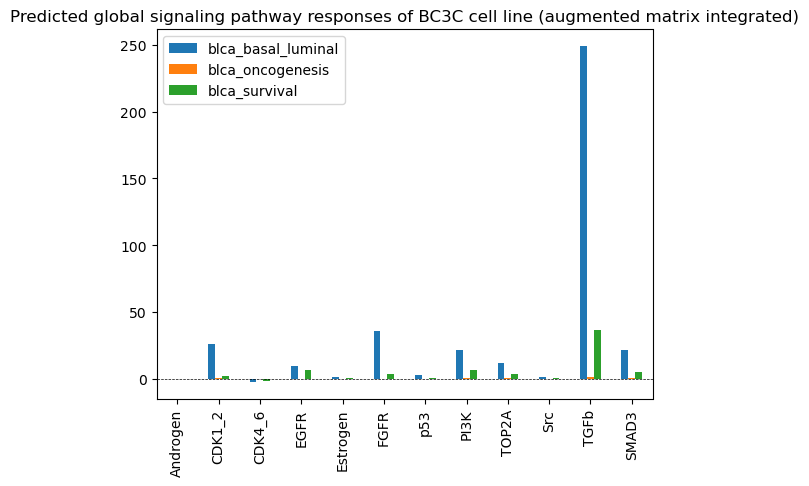

In [37]:
import matplotlib.pyplot as plt
t_df_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted global signaling pathway responses of {cell_line} cell line (augmented matrix integrated)")

In [34]:
display(rm_filt)
rm_subset=rm_filt[['Androgen','CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR','SMAD3',
       'PI3K', 'p53', 'TOP2A','Src','TGFb']]

,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,-1.0,0.000000,0.00000,-0.035480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
CDK1_2,0.0,-1.000000,0.00000,0.000000,0.000000,0.216342,0.206669,0.000000,0.000000,0.000000,0.000000,0.160057,0.0,0.0,0.0
CDK4_6,0.0,0.000000,-1.00000,-0.104579,0.138242,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
EGFR,0.0,0.000000,-0.28335,-1.000000,0.000000,0.450677,-0.262411,0.000000,0.000000,0.000000,0.000000,0.420575,0.0,0.0,0.0
Estrogen,0.0,0.000000,0.00000,0.000000,-1.000000,0.244510,0.133503,0.000000,0.000000,0.071651,0.000000,0.000000,0.0,0.0,0.0
FGFR,0.0,0.000000,0.00000,0.311785,0.000000,-1.000000,0.000000,0.072088,0.000000,0.000000,4.878345,0.245204,0.0,0.0,0.0
PI3K,0.0,0.336434,0.00000,-0.265739,0.000000,0.000000,-1.000000,0.000000,0.534515,0.000000,3.382833,0.218647,0.0,0.0,0.0
p53,0.0,0.000000,0.00000,0.140728,0.000000,0.000000,0.094689,-1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
TOP2A,0.0,0.000000,0.00000,-0.150715,0.096582,0.000000,0.135379,0.000000,-1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.0,0.000000,0.00000,0.131477,0.501187,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.0,0.0,0.0


In [35]:
rm_subset=rm_subset.loc[['blca_basal_luminal',	'blca_oncogenesis',	'blca_survival']]
rm_subset=rm_subset.T
display(rm_subset)

,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.000000,0.000000,0.000000
CDK1_2,18.417813,0.000000,0.000000
CDK4_6,0.000000,0.000000,0.000000
EGFR,0.000000,0.000000,5.860043
Estrogen,0.000000,-0.281935,0.000000
FGFR,25.756659,0.000000,0.000000
SMAD3,0.000000,0.455199,0.000000
PI3K,15.753010,0.382152,6.550473
p53,0.000000,-0.303500,0.000000
TOP2A,0.000000,0.000000,0.000000


Text(0.5, 1.0, 'Predicted local signaling pathway responses of BC3C cell line (augmented matrix integrated)')

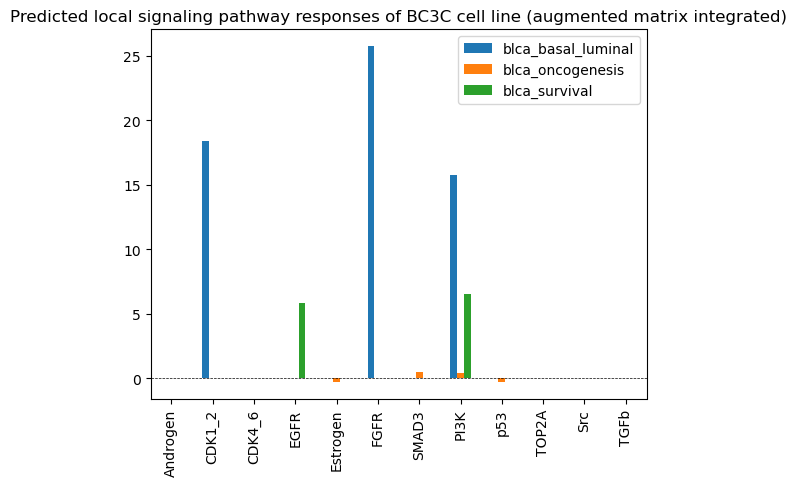

In [38]:
rm_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted local signaling pathway responses of {cell_line} cell line (augmented matrix integrated)")